In [1]:
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt

In [92]:
dataset = [
    'Drosophila_melanogaster',
    'Drosophila_erecta',
    'Drosophila_simulans',
    'Drosophila_ananassae',
    'Drosophila_ficusphila',
    'Drosophila_miranda',
    'Drosophila_persimilis',
    'Drosophila_pseudoobscura',
    'Drosophila_willistoni',
    'Drosophila_grimshawi',
    'Drosophila_virilis',
    'Musca_domestica'
]

In [93]:
def get_species(x):
    return x.split('/')[2].split('.')[0]

In [98]:
assemblies_gc = pd.read_csv('../data/dro_meta/assemblies_GC.tsv', sep = '\t', names=['species','GC content'])
assemblies_size = pd.read_csv('../data/dro_meta/assemblies_size.tsv', sep = '\t', names=['species','size'])
df = assemblies_gc.merge(assemblies_size, on ='species')
df.species = df.species.map(get_species)
df = df[df.species.isin(dataset)]
df.species = pd.Categorical(df['species'], categories=dataset, ordered=True)

<Axes: xlabel='size', ylabel='species'>

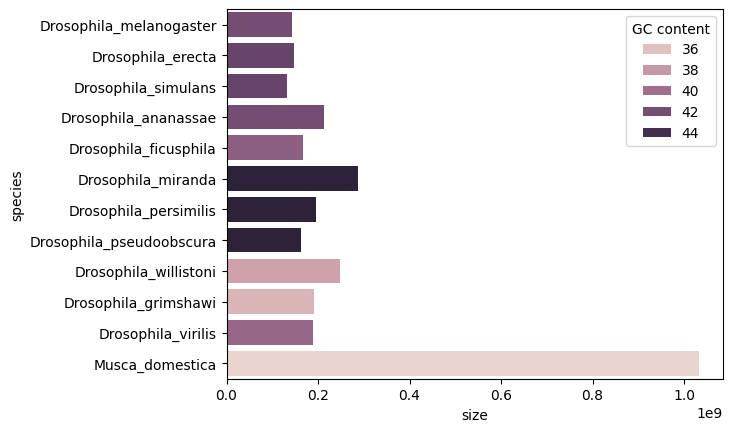

In [99]:
sns.barplot(data = df, 
            y = 'species',
            x = 'size',
            hue = 'GC content'
            )